In [1]:
import pandas as pd

df = pd.read_csv("dataset/processed_data_sim/random_trajectory.csv")


test_df = pd.read_csv("dataset/processed_data_sim/isolate_axis.csv")
df.head()

C:\Users\Gerso\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


,vx,vy,omega,vx_cmd,vy_cmd,omega_cmd,filtered_x,filtered_y,x,y,filtered_theta
0,0.0,0.0,0.0,0.0,0.0,0.0,-0.965379,0.536637,-0.965379,0.536637,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,-0.965379,0.536637,-0.965379,0.536637,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,-0.965379,0.536637,-0.965379,0.536637,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,-0.965379,0.536637,-0.965379,0.536637,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,-0.965379,0.536637,-0.965379,0.536637,0.0


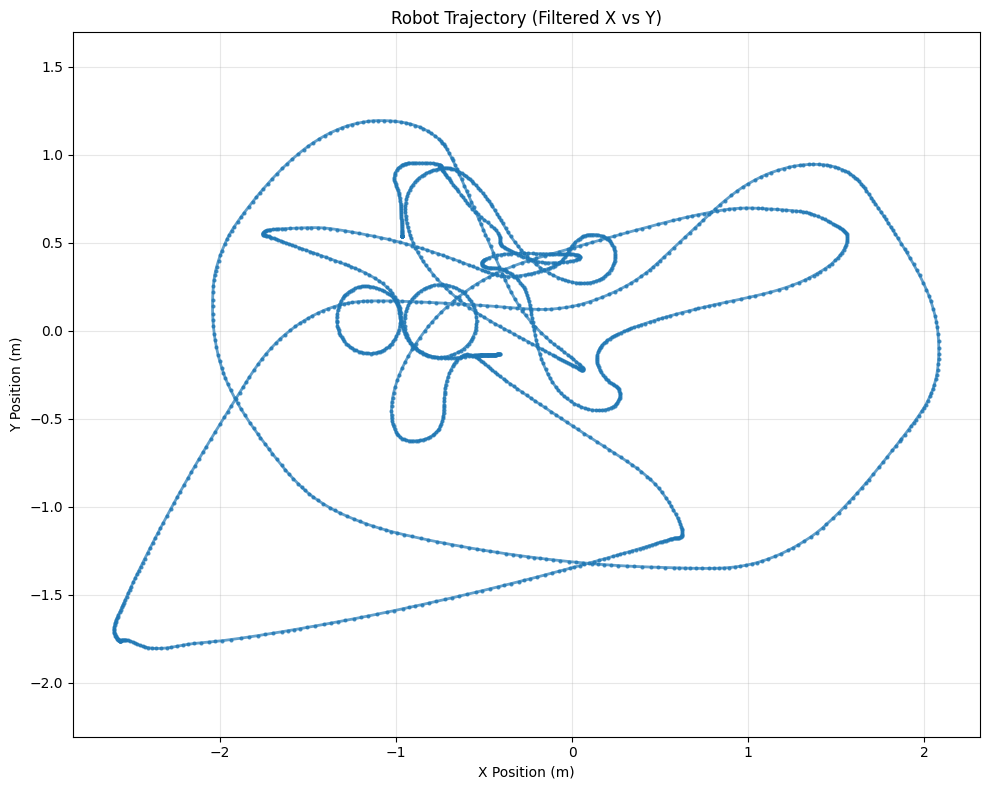

In [2]:
import matplotlib.pyplot as plt
# Create the plot
plt.figure(figsize=(10, 8))
plt.plot(df['filtered_x'], df['filtered_y'], linewidth=2, marker='o', markersize=2, alpha=0.7)
plt.xlabel('X Position (m)')
plt.ylabel('Y Position (m)')
plt.title('Robot Trajectory (Filtered X vs Y)')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

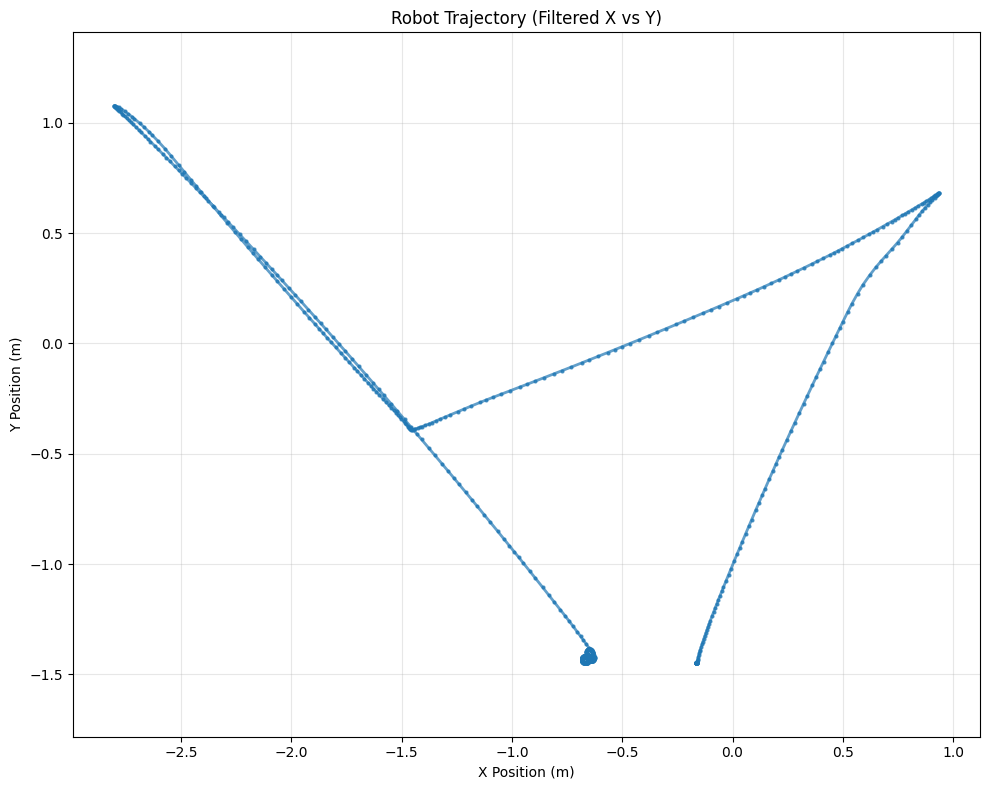

In [3]:
import matplotlib.pyplot as plt
# Create the plot
plt.figure(figsize=(10, 8))
plt.plot(test_df['filtered_x'], test_df['filtered_y'], linewidth=2, marker='o', markersize=2, alpha=0.7)
plt.xlabel('X Position (m)')
plt.ylabel('Y Position (m)')
plt.title('Robot Trajectory (Filtered X vs Y)')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [4]:
import torch
from torch.utils.data import Dataset
import pandas as pd
from typing import Tuple
from utils.utils import State, Command

class TrajectoryDataset(Dataset):
    def __init__(self, df: pd.DataFrame, window_length: int, target_length: int):
        """
        Args:
            df: The trajectory dataframe.
            window_length: How many historical steps to use as input.
            target_length: How many future steps to predict (the autoregressive horizon).
        """
        self.window_length = window_length
        self.target_length = target_length
        
        # The total sequence length needed for one sample
        self.total_seq_len = window_length + target_length
        
        # Adjust total samples so we don't index out of bounds at the end of the dataframe
        self.num_samples = len(df) - self.total_seq_len + 1
        
        if self.num_samples <= 0:
            raise ValueError(
                f"DataFrame length ({len(df)}) must be >= "
                f"window_length + target_length ({self.total_seq_len})."
            )

        state_cols = ['filtered_x', 'filtered_y', 'filtered_theta', 'vx', 'vy', 'omega']
        cmd_cols = ['vx_cmd', 'vy_cmd', 'omega_cmd']
        
        self.state_data = torch.tensor(df[state_cols].values, dtype=torch.float32)
        self.cmd_data = torch.tensor(df[cmd_cols].values, dtype=torch.float32)

    def __len__(self) -> int:
        return self.num_samples

    def __getitem__(self, idx: int) -> Tuple[State, Command, State, Command]:
        """
        Retrieves a historical sequence and a future target sequence.
        
        Returns:
            input_states: Historical states shape (window_length,)
            input_cmds: Historical commands shape (window_length,)
            target_states: Future ground-truth states shape (target_length,)
            future_cmds: Future planned commands shape (target_length,)
        """
        # Calculate the split indices
        mid_idx = idx + self.window_length
        end_idx = mid_idx + self.target_length
        
        # Slice the historical inputs
        raw_input_state = self.state_data[idx:mid_idx]
        raw_input_cmd = self.cmd_data[idx:mid_idx]
        
        # Slice the future targets (and the future commands driving them)
        raw_target_state = self.state_data[mid_idx:end_idx]
        raw_future_cmd = self.cmd_data[mid_idx:end_idx]
        
        return (
            State.from_tensor(raw_input_state),
            Command.from_tensor(raw_input_cmd),
            State.from_tensor(raw_target_state),
            Command.from_tensor(raw_future_cmd)
        )

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm # For progress bars
from typing import List, Tuple

class ModelTrainer:
    def __init__(
        self, 
        model: nn.Module, 
        train_loader: DataLoader, 
        val_loader: DataLoader, 
        criterion,
        learning_rate: float = 1e-3, 
        device: str = "cuda" if torch.cuda.is_available() else "cpu"
    ):
        self.device = torch.device(device)
        self.model = model.to(self.device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        
        # Standard regression loss. 
        # Note: Be careful with MSE on the `theta` angle due to the -pi/pi wrap.

        self.criterion = criterion
        
        self.optimizer = optim.Adam(self.model.parameters(), lr=learning_rate)


    def train_epoch(self) -> float:
        self.model.train()
        running_loss = 0.0
        
        # Wrap loader with tqdm for a nice visual progress bar
        pbar = tqdm(self.train_loader, desc="Training")
        
        # Unpack the 4 sequences from our updated dataset
        for input_states, input_cmds, target_states, future_cmds in pbar:
            
            # 1. Convert NamedTuples to tensors and move to device
            curr_state_seq = input_states.as_tensor().to(self.device)
            curr_cmd_seq = input_cmds.as_tensor().to(self.device)
            
            target_state_seq = target_states.as_tensor().to(self.device)
            future_cmd_seq = future_cmds.as_tensor().to(self.device)
            
            # 2. Zero the gradients
            self.optimizer.zero_grad()
            
            # Increase this while training
            target_length = target_state_seq.shape[1] # How many steps into the future
            predictions = []
            
            # 3. Autoregressive Loop
            for t in range(target_length):
                # Forward pass: predict the next single step
                # (Your CNNModel returns a `State` NamedTuple)
                pred_state = self.model(curr_state_seq, curr_cmd_seq)
                
                # Convert predicted State to tensor and add a sequence dimension
                # Shape becomes: (batch_size, 1, 6)
                pred_state_tensor = pred_state.as_tensor().unsqueeze(1)
                predictions.append(pred_state_tensor)
                
                # Roll the state window: drop oldest step (index 0), append new prediction
                curr_state_seq = torch.cat([curr_state_seq[:, 1:, :], pred_state_tensor], dim=1)
                
                # Roll the command window: drop oldest step, append the upcoming known command
                next_cmd = future_cmd_seq[:, t:t+1, :]
                curr_cmd_seq = torch.cat([curr_cmd_seq[:, 1:, :], next_cmd], dim=1)
                
            # 4. Concatenate all step-by-step predictions into one sequence tensor
            # Final Shape: (batch_size, target_length, 6)
            all_predictions = torch.cat(predictions, dim=1)
            
            # 5. Compute loss across the entire predicted trajectory 
            # (We bypass _calculate_loss here since we are comparing full sequence tensors)
            loss = self.criterion(all_predictions, target_state_seq)
            
            # 6. Backward pass and optimization
            loss.backward()
            self.optimizer.step()
            
            running_loss += loss.item()
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})
            
        return running_loss / len(self.train_loader)

    def validate_epoch(self) -> float:
        self.model.eval()
        running_loss = 0.0
        
        # Disable gradient calculation for memory efficiency and speed
        with torch.no_grad():
            # Unpack the 4 sequences from the updated dataset
            for input_states, input_cmds, target_states, future_cmds in self.val_loader:
                
                # 1. Convert NamedTuples to tensors and move to device
                curr_state_seq = input_states.as_tensor().to(self.device)
                curr_cmd_seq = input_cmds.as_tensor().to(self.device)
                
                target_state_seq = target_states.as_tensor().to(self.device)
                future_cmd_seq = future_cmds.as_tensor().to(self.device)
                
                target_length = target_state_seq.shape[1] 
                predictions = []
                
                # 2. Autoregressive Loop
                for t in range(target_length):
                    # Forward pass: predict the next single step
                    pred_state = self.model(curr_state_seq, curr_cmd_seq)
                    
                    # Convert predicted State to tensor and add a sequence dimension
                    pred_state_tensor = pred_state.as_tensor().unsqueeze(1)
                    predictions.append(pred_state_tensor)
                    
                    # Roll the state window: drop oldest step, append new prediction
                    curr_state_seq = torch.cat([curr_state_seq[:, 1:, :], pred_state_tensor], dim=1)
                    
                    # Roll the command window: drop oldest step, append the upcoming known command
                    next_cmd = future_cmd_seq[:, t:t+1, :]
                    curr_cmd_seq = torch.cat([curr_cmd_seq[:, 1:, :], next_cmd], dim=1)
                    
                # 3. Concatenate all step-by-step predictions into one sequence tensor
                all_predictions = torch.cat(predictions, dim=1)
                
                # 4. Compute trajectory loss using your custom wrapper
                loss = self.criterion(all_predictions, target_state_seq)
                
                running_loss += loss.item()
                
        return running_loss / len(self.val_loader)

    def fit(self, epochs: int) -> Tuple[List[float], List[float]]:
        """
        Main training loop.
        
        Returns:
            Tuple[List[float], List[float]]: A tuple containing the training 
            and validation loss histories across all epochs.
        """
        print(f"Training on device: {self.device}")
        
        train_losses = []
        val_losses = []
        
        for epoch in range(1, epochs + 1):
            print(f"\n--- Epoch {epoch}/{epochs} ---")
            
            train_loss = self.train_epoch()
            val_loss = self.validate_epoch()
            
            # Record the losses for this epoch
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            
            print(f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
            
        return train_losses, val_losses

In [11]:
import torch
from torch.utils.data import DataLoader, random_split

window_length = 15
batch_size = 32
target_length = 5

# 1. Instantiate the Dataset with the FULL dataframe first.
# This ensures the internal 10-step sequences are still mathematically valid.
train_dataset = TrajectoryDataset(test_df, window_length=window_length, target_length=target_length)
test_dataset = TrajectoryDataset(df, window_length=window_length, target_length=target_length)


# 4. Create the DataLoaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False 
)

print(f"Total training samples: {len(train_dataset)}")
print(f"Total test samples: {len(test_dataset)}")
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

Total training samples: 879
Total test samples: 1720
Train batches: 28 | Test batches: 54


In [7]:
import torch
import torch.nn as nn

class TrajectoryLoss(nn.Module):
    """
    Computes MSE for linear variables and wrapped Angular MSE for angular variables.
    Works seamlessly with both (Batch, Features) and (Batch, Sequence, Features) tensors.
    """
    def __init__(self, angle_index: int = 2):
        super().__init__()
        # In your State tuple, theta is at index 2: (x, y, theta, vx, vy, omega)
        self.angle_index = angle_index
        
        # We use reduction='none' so we can manipulate specific columns before averaging
        self.mse = nn.MSELoss(reduction='none')

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        # 1. Compute standard squared errors for EVERYTHING
        squared_errors = self.mse(pred, target)
        
        # 2. Extract just the angle columns using ellipsis to handle any tensor dimensions
        pred_angle = pred[..., self.angle_index]
        target_angle = target[..., self.angle_index]
        
        # 3. Calculate the shortest angular difference (wrapped between -pi and pi)
        diff = target_angle - pred_angle
        wrapped_diff = torch.atan2(torch.sin(diff), torch.cos(diff))
        
        # 4. Replace the standard angle error with the squared wrapped error
        squared_errors[..., self.angle_index] = wrapped_diff ** 2
        
        # 5. Return the mean across all batches, sequences, and features
        return torch.mean(squared_errors)

Training on device: cpu

--- Epoch 1/5 ---


Training: 100%|██████████| 28/28 [00:00<00:00, 55.11it/s, loss=0.0156]


Train Loss: 0.032748 | Val Loss: 0.049151

--- Epoch 2/5 ---


Training: 100%|██████████| 28/28 [00:00<00:00, 51.92it/s, loss=0.0125]


Train Loss: 0.017679 | Val Loss: 0.042628

--- Epoch 3/5 ---


...

Train Loss: 0.013331 | Val Loss: 0.042339

--- Epoch 4/5 ---


Training: 100%|██████████| 28/28 [00:00<00:00, 51.32it/s, loss=0.0093]


Train Loss: 0.011600 | Val Loss: 0.041658

--- Epoch 5/5 ---


Training: 100%|██████████| 28/28 [00:00<00:00, 50.92it/s, loss=0.0100]


Train Loss: 0.010890 | Val Loss: 0.046888


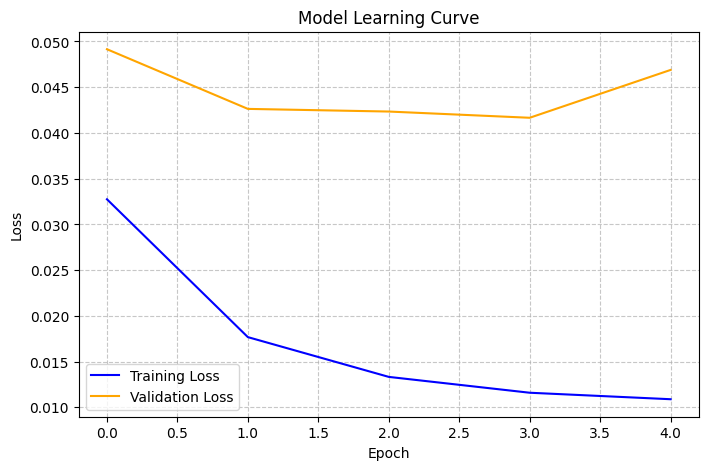

In [12]:
from models.cnn_model import CNNModel

# 1. Initialize your specific model with the dt (time delta)
dt = 0.016  # Example timestep
model = CNNModel(dt=dt)

# 3. Initialize the trainer
trainer = ModelTrainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    learning_rate=0.001,
    criterion=TrajectoryLoss(),
    device="cpu"
)

import matplotlib.pyplot as plt

# Run training and capture the returned histories
train_history, val_history = trainer.fit(epochs=5)

# Plot the learning curves
plt.figure(figsize=(8, 5))
plt.plot(train_history, label="Training Loss", color="blue")
plt.plot(val_history, label="Validation Loss", color="orange")
plt.title("Model Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

Generating trajectory plots from test data...


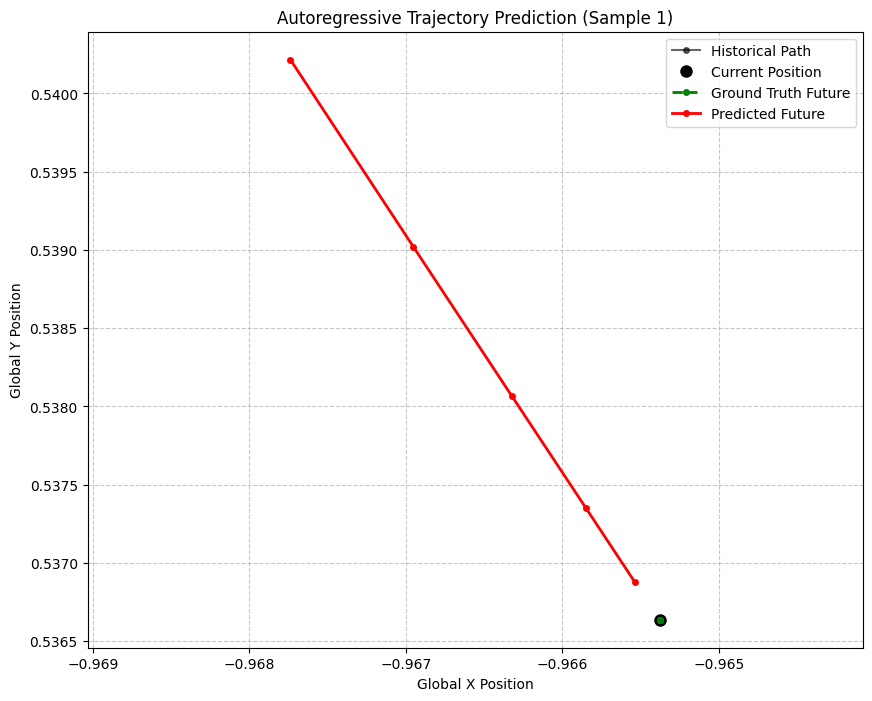

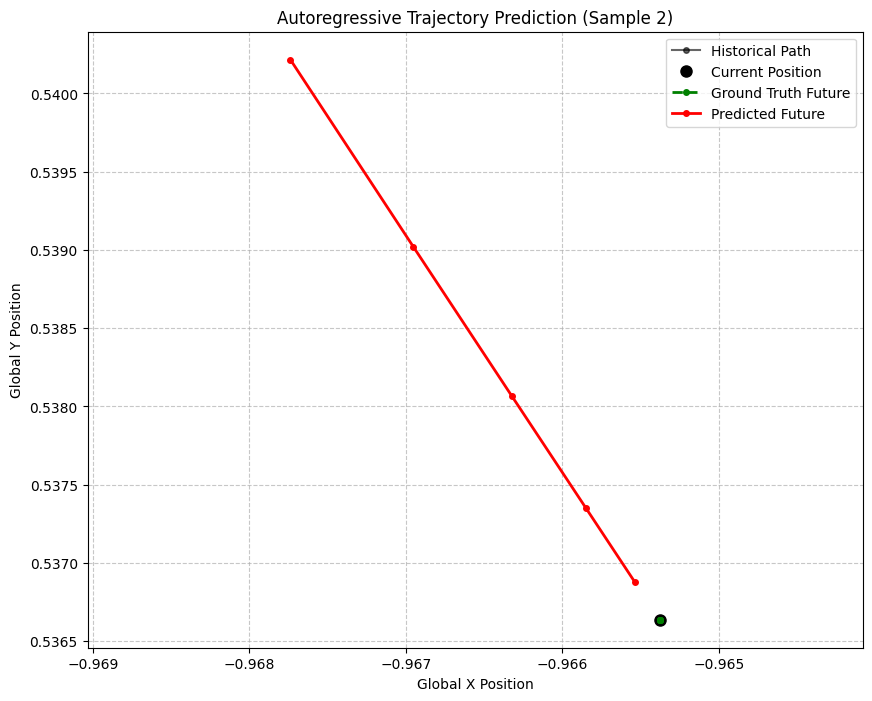

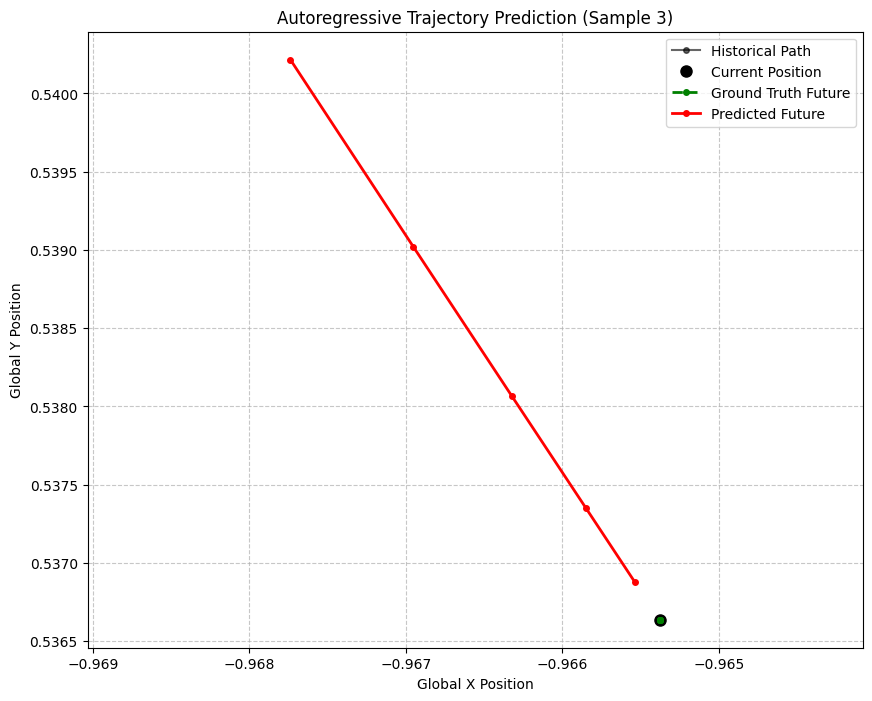

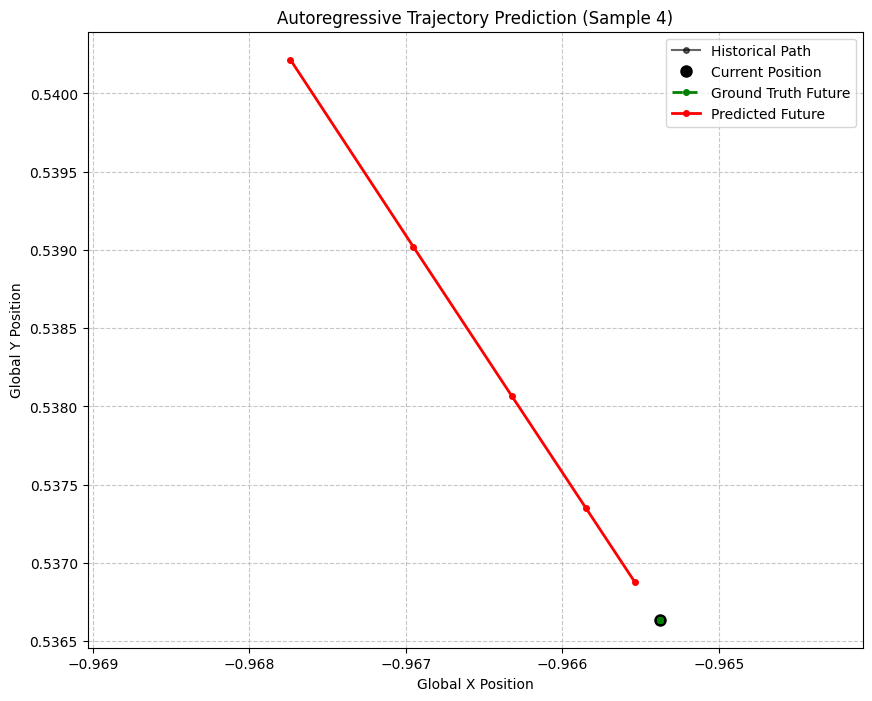

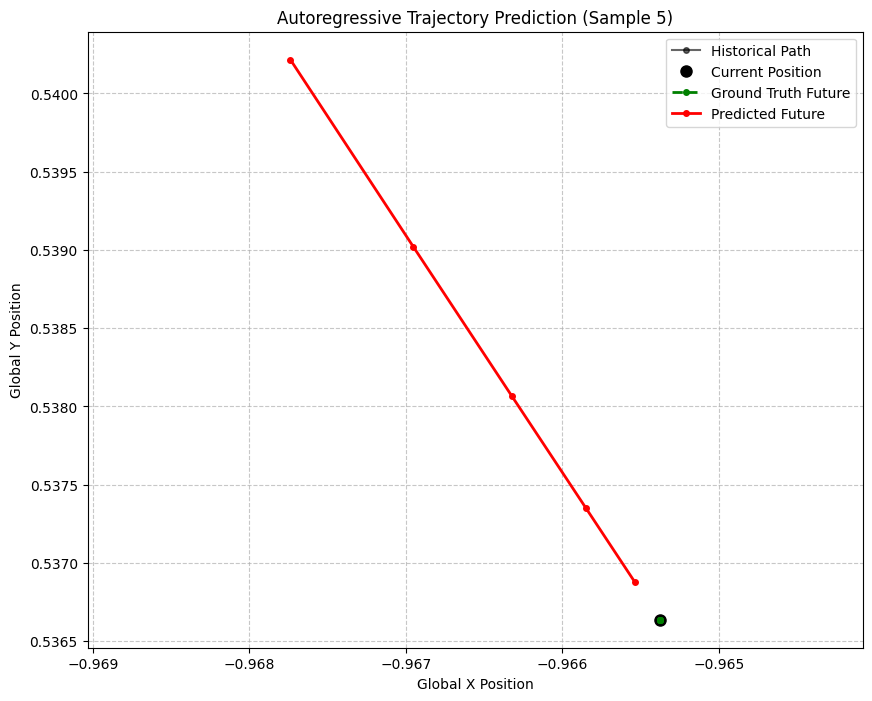

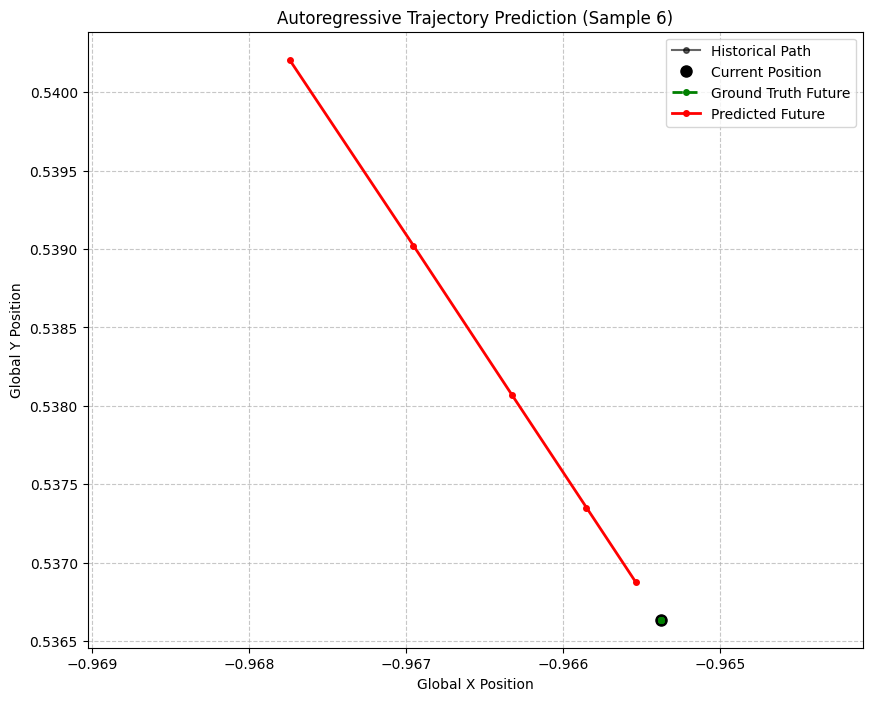

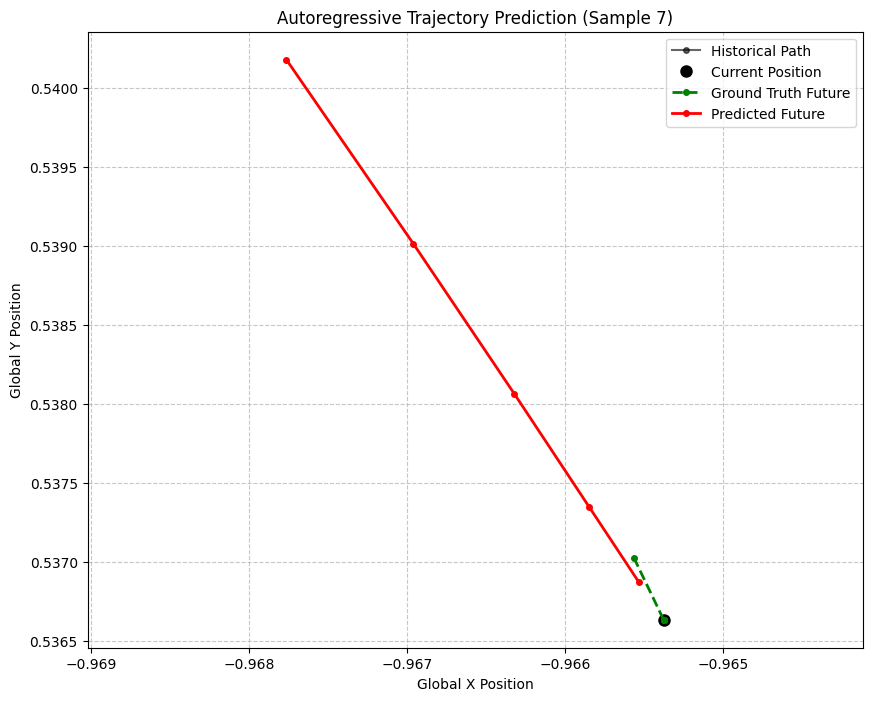

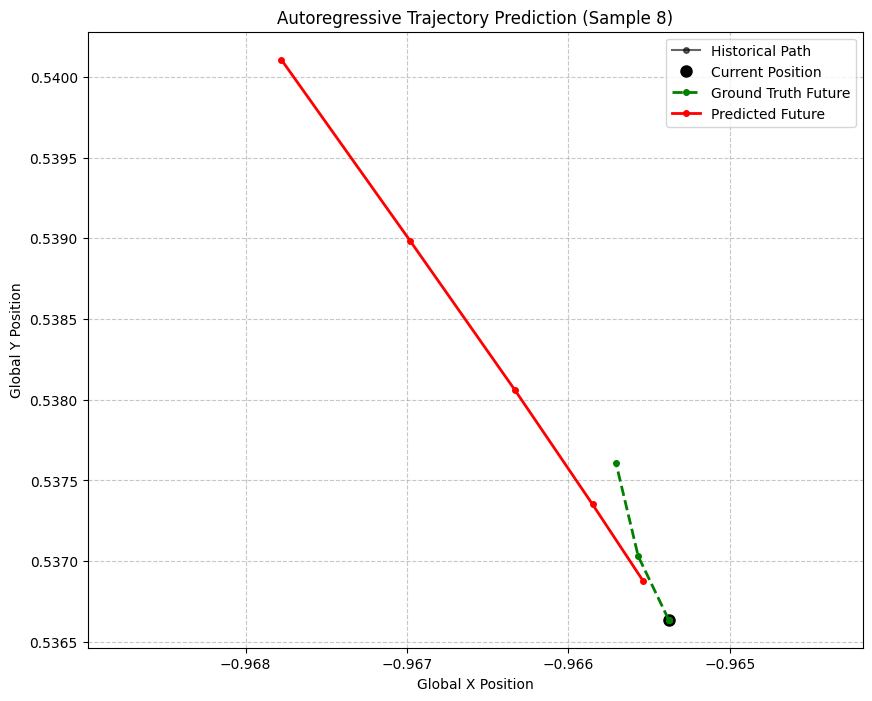

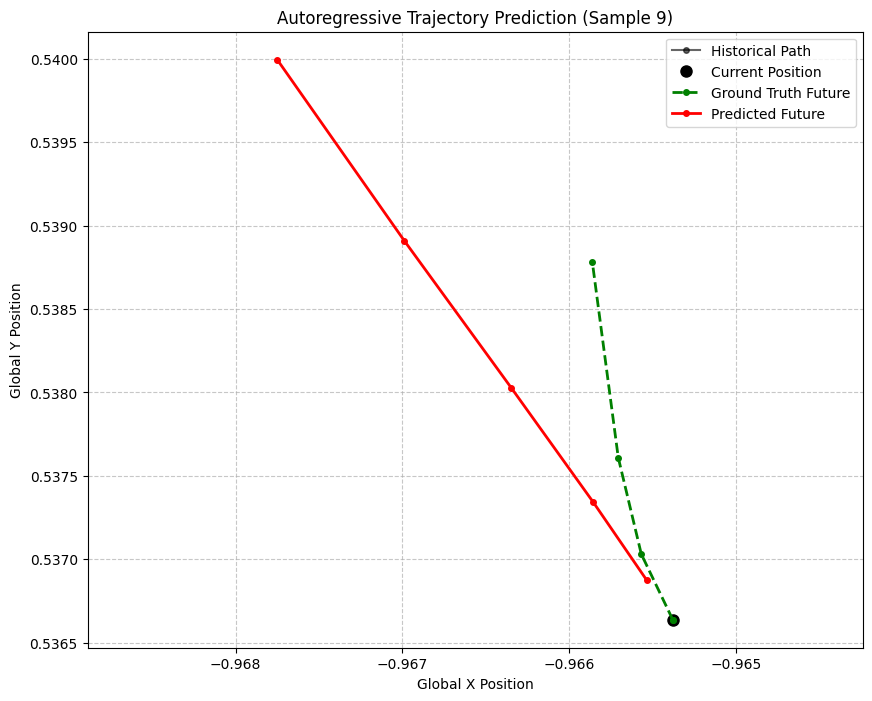

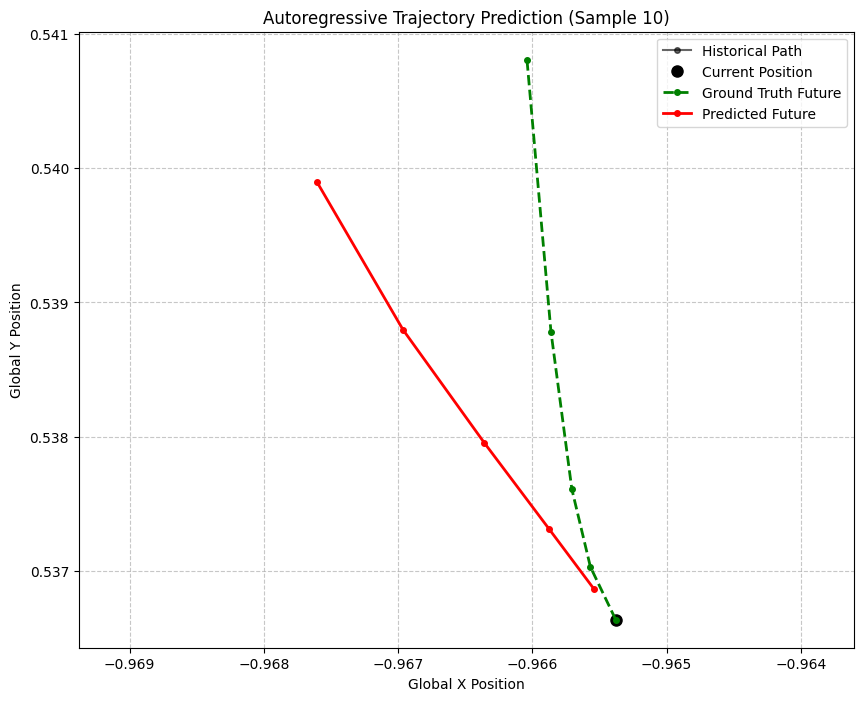

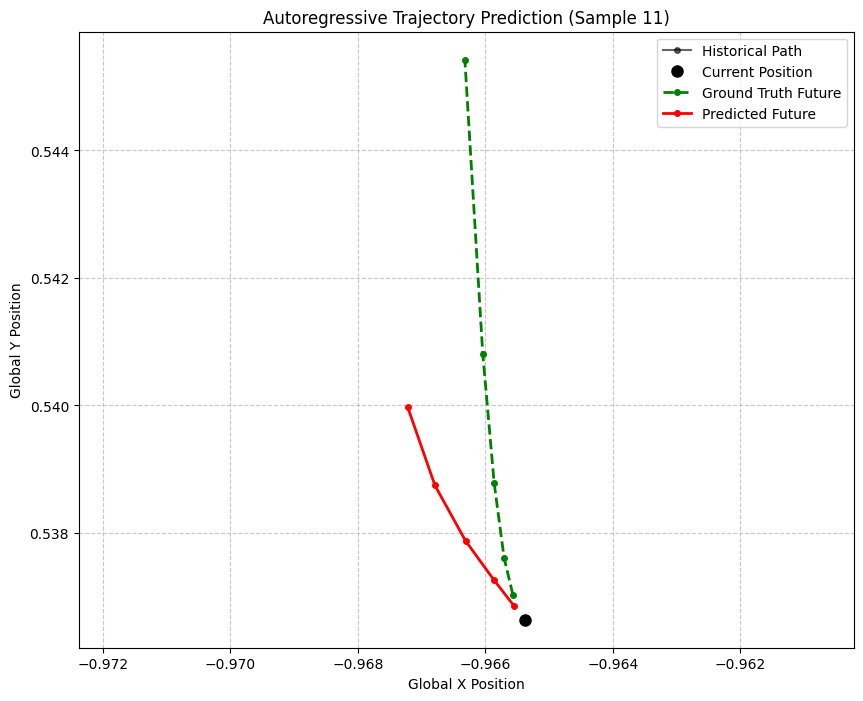

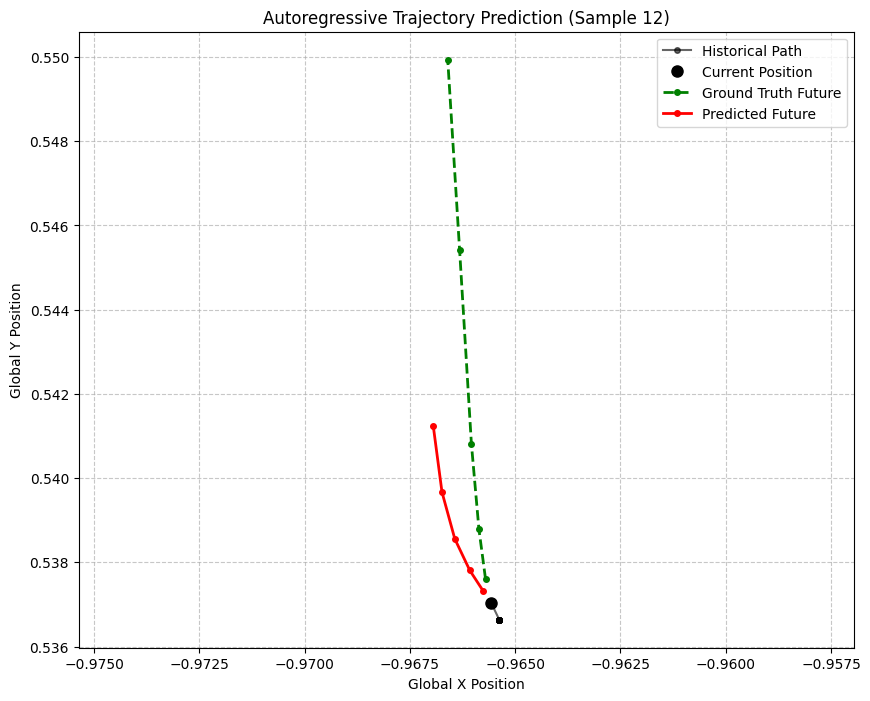

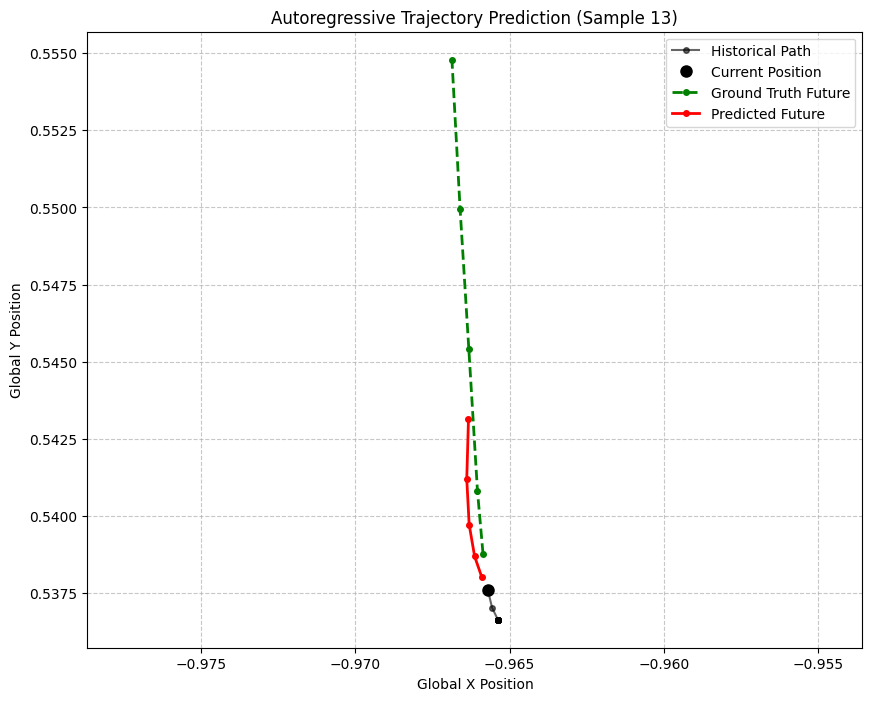

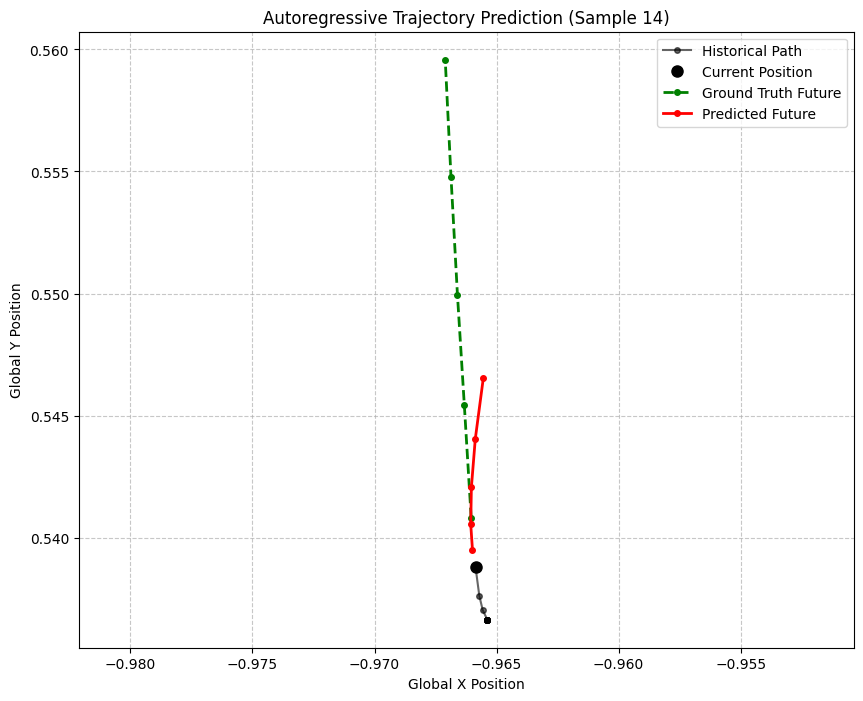

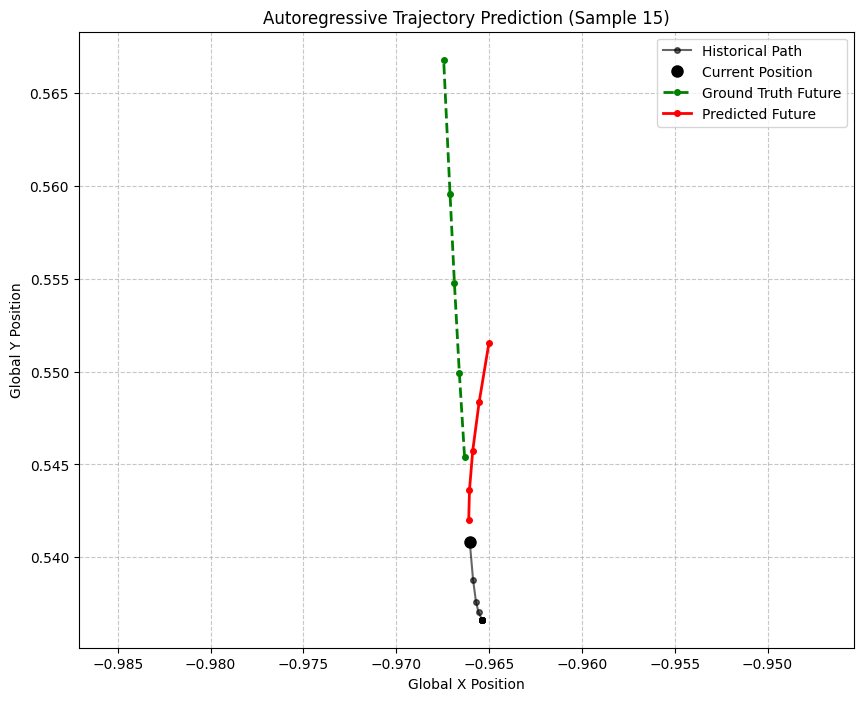

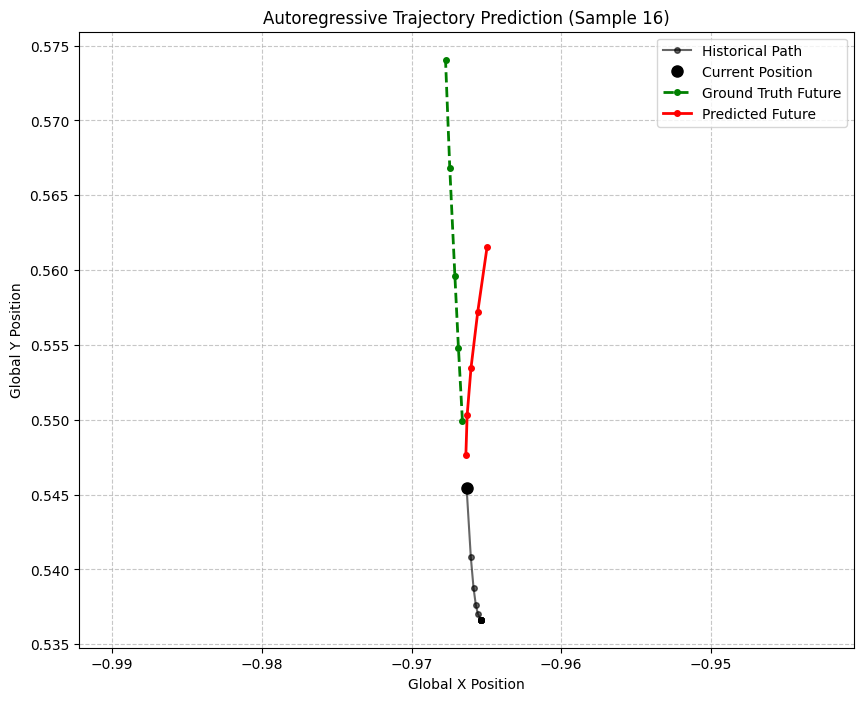

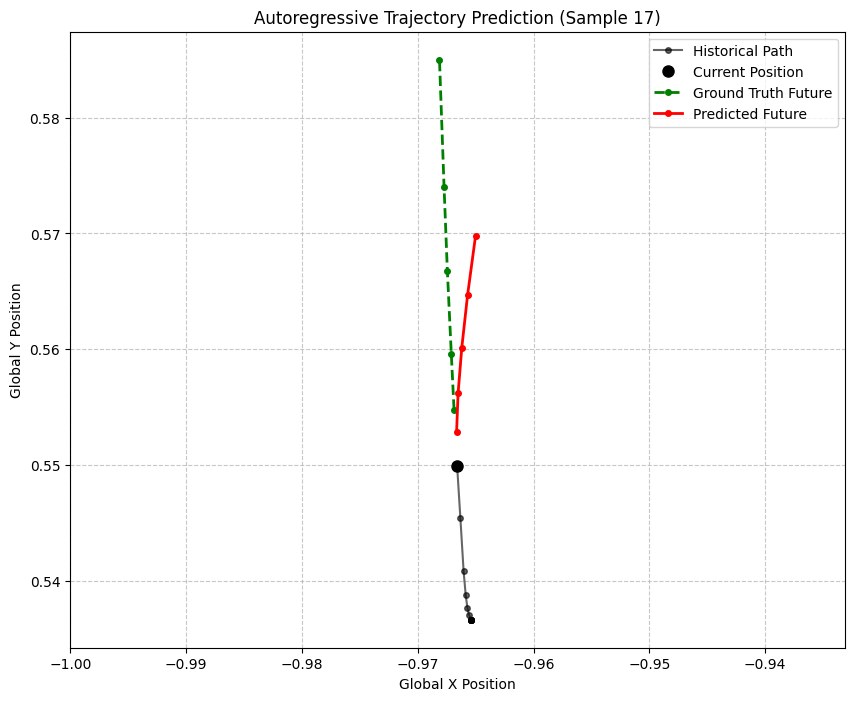

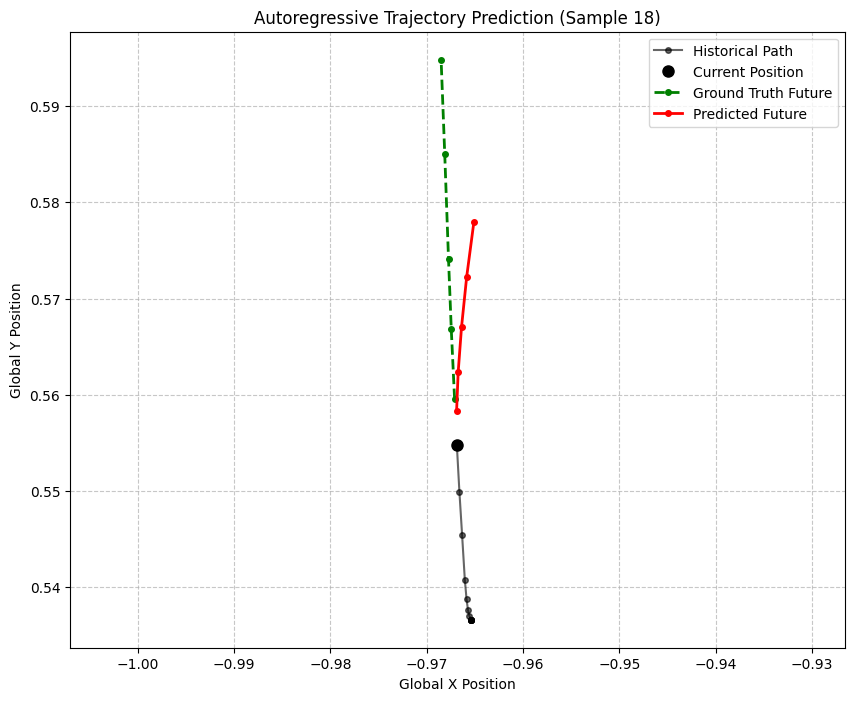

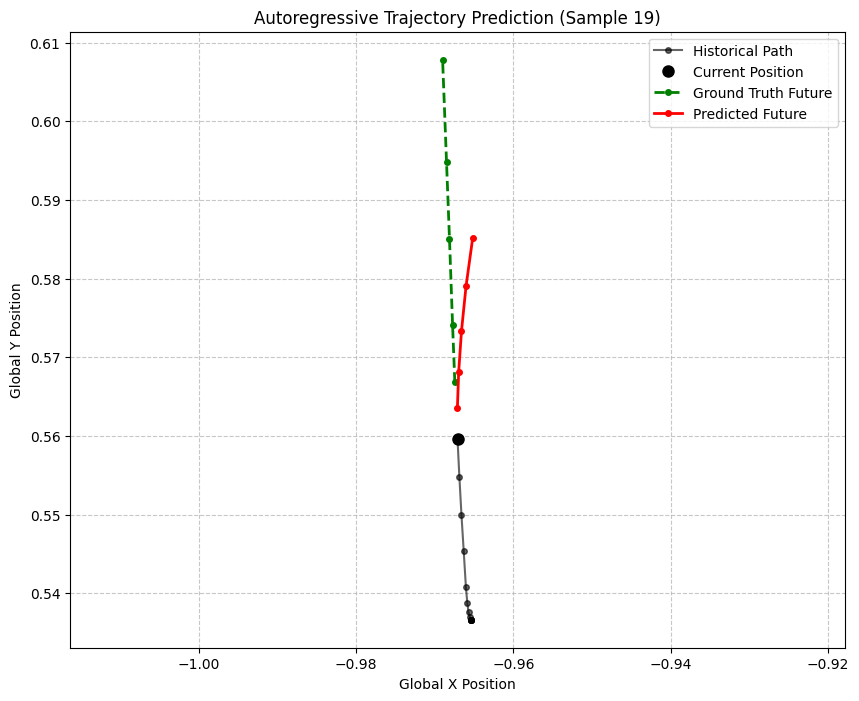

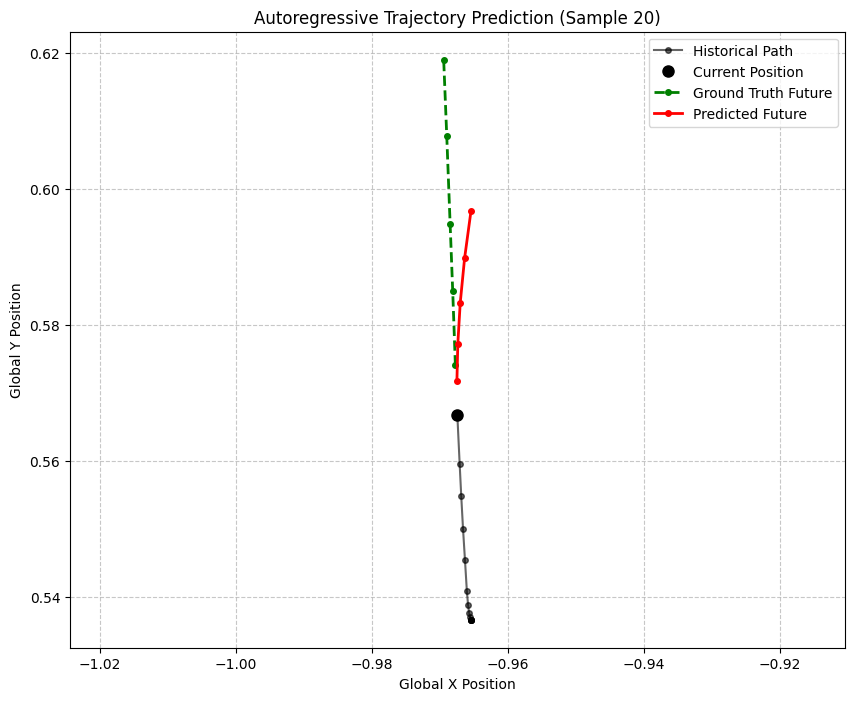

In [14]:
import torch
import matplotlib.pyplot as plt

def plot_trajectory_predictions(model, test_loader, device='cpu', num_plots=1):
    """
    Evaluates the model autoregressively on a batch from the test_loader 
    and plots the predicted vs. ground truth X-Y trajectories.
    """
    model.eval()
    model.to(device)
    
    # Grab a single batch of data
    # (Using next(iter()) is the standard way to pull one batch manually)
    try:
        input_states, input_cmds, target_states, future_cmds = next(iter(test_loader))
    except StopIteration:
        print("Test loader is empty!")
        return

    with torch.no_grad():
        # 1. Convert to tensors and move to device
        curr_state_seq = input_states.as_tensor().to(device)
        curr_cmd_seq = input_cmds.as_tensor().to(device)
        target_state_seq = target_states.as_tensor().to(device)
        future_cmd_seq = future_cmds.as_tensor().to(device)
        
        target_length = target_state_seq.shape[1]
        predictions = []
        
        # Save a copy of the original history for plotting before we mutate it
        history_states_np = curr_state_seq.cpu().numpy()
        
        # 2. Autoregressive loop
        for t in range(target_length):
            pred_state = model(curr_state_seq, curr_cmd_seq)
            pred_state_tensor = pred_state.as_tensor().unsqueeze(1)
            predictions.append(pred_state_tensor)
            
            # Roll windows
            curr_state_seq = torch.cat([curr_state_seq[:, 1:, :], pred_state_tensor], dim=1)
            next_cmd = future_cmd_seq[:, t:t+1, :]
            curr_cmd_seq = torch.cat([curr_cmd_seq[:, 1:, :], next_cmd], dim=1)
            
        all_predictions = torch.cat(predictions, dim=1).cpu().numpy()
        target_states_np = target_state_seq.cpu().numpy()

    # 3. Plotting
    # Limit num_plots to the batch size to avoid out-of-bounds errors
    num_plots = min(num_plots, history_states_np.shape[0])
    
    for i in range(num_plots):
        plt.figure(figsize=(10, 8))
        
        # Extract X (index 0) and Y (index 1) arrays for the specific batch item 'i'
        hist_x = history_states_np[i, :, 0]
        hist_y = history_states_np[i, :, 1]
        
        true_future_x = target_states_np[i, :, 0]
        true_future_y = target_states_np[i, :, 1]
        
        pred_future_x = all_predictions[i, :, 0]
        pred_future_y = all_predictions[i, :, 1]
        
        # Plot History
        plt.plot(hist_x, hist_y, 'k.-', label='Historical Path', markersize=8, alpha=0.6)
        # Highlight the final historical point (the starting point for the prediction)
        plt.plot(hist_x[-1], hist_y[-1], 'ko', markersize=8, label='Current Position')
        
        # Plot Ground Truth Future
        plt.plot(true_future_x, true_future_y, 'g.--', label='Ground Truth Future', markersize=8, linewidth=2)
        
        # Plot Predicted Future
        plt.plot(pred_future_x, pred_future_y, 'r.-', label='Predicted Future', markersize=8, linewidth=2)
        
        plt.title(f"Autoregressive Trajectory Prediction (Sample {i+1})")
        plt.xlabel("Global X Position")
        plt.ylabel("Global Y Position")
        
        # Ensure the aspect ratio is equal so turns don't look warped
        plt.axis('equal') 
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()
        plt.show()

# Assuming you just finished trainer.fit(epochs=50)
print("Generating trajectory plots from test data...")

# Generate 3 separate plots from the test batch
plot_trajectory_predictions(
    model=model, 
    test_loader=test_loader, 
    device="cuda" if torch.cuda.is_available() else "cpu",
    num_plots=20
)